# Phase 3 — Clustering Model
**Project: What Does Underground Sound Like?**

We'll use **K-Means clustering** — an unsupervised ML algorithm that groups songs by sonic similarity, without being told what the groups are.

Then we use **PCA** (Principal Component Analysis) to flatten the 7-dimensional audio feature space down to 2D so we can actually see the clusters.

**Why this is impressive:** We're not just labelling by popularity — we're asking the *audio features themselves* to reveal hidden structure in the music.

## Cell 1 — Imports and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn is the main ML library in Python
from sklearn.preprocessing import StandardScaler   # Normalise features
from sklearn.cluster import KMeans                 # The clustering algorithm
from sklearn.decomposition import PCA             # Dimensionality reduction
from sklearn.metrics import silhouette_score      # Measures cluster quality

%matplotlib inline
sns.set_theme(style='whitegrid')

C_UNDERGROUND = '#5B4CF0'
C_MAINSTREAM  = '#E8593C'

df_model = pd.read_csv('df_model.csv')
print(f'Loaded {len(df_model):,} songs (underground + mainstream)')
print(df_model['label'].value_counts())

Loaded 13,321 songs (underground + mainstream)
label
mainstream     6838
underground    6483
Name: count, dtype: int64


---
## Cell 2 — Select features and scale them
**Why scale?** K-Means measures distance between songs. If `tempo` ranges from 60–200 and `danceability` ranges from 0–1, tempo will dominate the distance calculation just because its numbers are bigger. Scaling (StandardScaler) converts everything to the same range (mean=0, std=1) so all features contribute equally.

In [2]:
# The audio features we'll feed into the model
FEATURES = ['danceability', 'energy', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence']

# Extract the feature matrix (X)
X = df_model[FEATURES].values  # .values converts the DataFrame to a plain numpy array

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# fit_transform = learn the mean/std from the data, then apply the scaling

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]:,} songs × {X_scaled.shape[1]} features')
print(f'\nBefore scaling — tempo range: {df_model["danceability"].min():.2f} to {df_model["danceability"].max():.2f}')
print(f'After scaling  — danceability range: {X_scaled[:, 0].min():.2f} to {X_scaled[:, 0].max():.2f}')

Feature matrix shape: (13321, 7)
  13,321 songs × 7 features

Before scaling — tempo range: 0.08 to 0.98
After scaling  — danceability range: -3.97 to 2.23


---
## Cell 3 — Find the right number of clusters (Elbow Method)
K-Means needs you to tell it how many clusters (K) to find. We don't know the answer — so we try K from 2 to 10 and measure the 'inertia' (how tightly packed the clusters are). The 'elbow' in the curve is where adding more clusters stops helping much.

Testing cluster counts...
  K=2: inertia=79416, silhouette=0.189
  K=3: inertia=68372, silhouette=0.173
  K=4: inertia=58926, silhouette=0.183
  K=5: inertia=51376, silhouette=0.200
  K=6: inertia=46062, silhouette=0.206
  K=7: inertia=42751, silhouette=0.190
  K=8: inertia=40726, silhouette=0.186
  K=9: inertia=39198, silhouette=0.191
  K=10: inertia=37705, silhouette=0.180


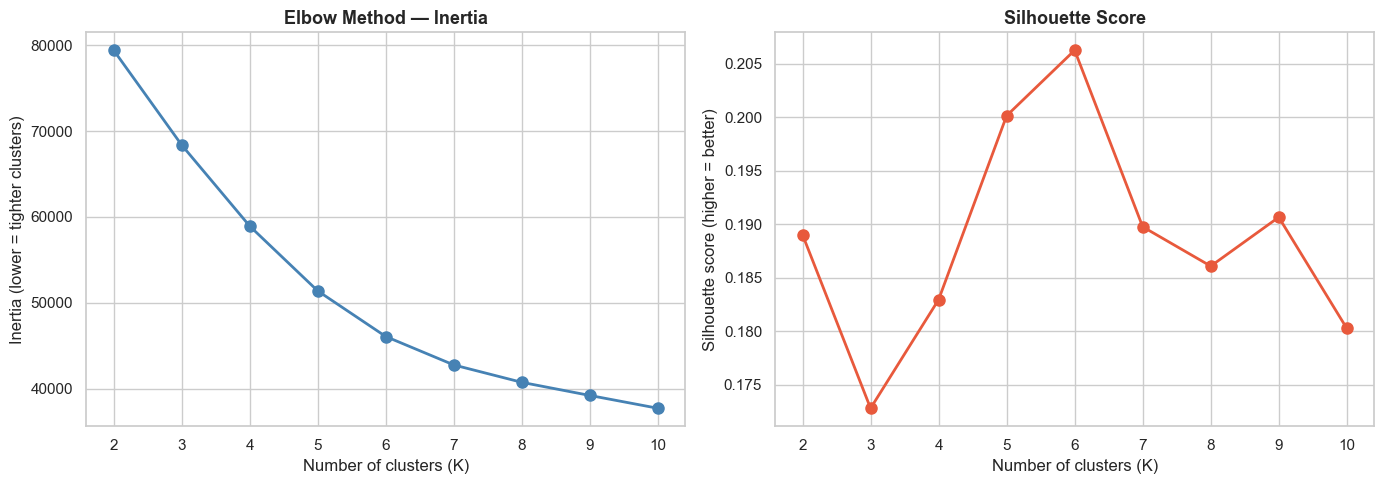


Best K by silhouette score: K=6


In [3]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print('Testing cluster counts...')
for k in K_range:
    # n_init=10 runs the algorithm 10 times with different starts, picks the best
    # random_state=42 makes it reproducible (same result every run)
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels, sample_size=3000, random_state=42))
    print(f'  K={k}: inertia={kmeans.inertia_:.0f}, silhouette={silhouette_scores[-1]:.3f}')

# Plot the elbow curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia (lower = tighter clusters)')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), silhouette_scores, 'o-', color='#E8593C', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score (higher = better)')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('output_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
print(f'\nBest K by silhouette score: K={best_k}')

---
## Cell 4 — Train the final K-Means model

In [10]:
# Use K=6 (you can also use best_k — pick whichever makes most intuitive sense)
# 4 clusters is a good story: e.g. 'energetic underground', 'chill underground',
# 'polished mainstream', 'danceable mainstream'
K = 6

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster assignment back to the DataFrame
df_model = df_model.copy()
df_model['cluster'] = cluster_labels

print(f'K-Means trained with K={K}')
print('\nSongs per cluster:')
print(df_model['cluster'].value_counts().sort_index())

print('\nCluster composition (underground vs mainstream):')
print(df_model.groupby(['cluster', 'label']).size().unstack(fill_value=0))

K-Means trained with K=6

Songs per cluster:
cluster
0    1006
1    1829
2     969
3    3479
4    1649
5    4389
Name: count, dtype: int64

Cluster composition (underground vs mainstream):
label    mainstream  underground
cluster                         
0               461          545
1              1002          827
2               198          771
3              1759         1720
4               936          713
5              2482         1907


---
## Cell 5 — PCA: reduce to 2D so we can plot it
We have 7 audio features (7 dimensions). Humans can't see 7D. PCA finds the 2 directions that capture the most variation in the data and projects everything onto those 2 axes.

In [11]:
# Reduce from 7 dimensions to 2
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Original dimensions: {X_scaled.shape[1]}')
print(f'After PCA:           {X_pca.shape[1]}')
print(f'\nVariance explained:')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%')

# What does each PCA axis represent?
print('\nPCA component loadings (which features contribute most to each axis):')
loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=['PC1', 'PC2'])
print(loadings.round(3))

Original dimensions: 7
After PCA:           2

Variance explained:
  PC1: 23.0%
  PC2: 20.8%
  Total: 43.8%

PCA component loadings (which features contribute most to each axis):
                    PC1    PC2
danceability     -0.056  0.611
energy            0.694  0.022
speechiness      -0.060  0.372
acousticness     -0.643 -0.021
instrumentalness  0.105 -0.316
liveness          0.244 -0.154
valence           0.164  0.602


---
## Cell 6 — Visualise clusters in 2D
The centrepiece of your project's visual output.

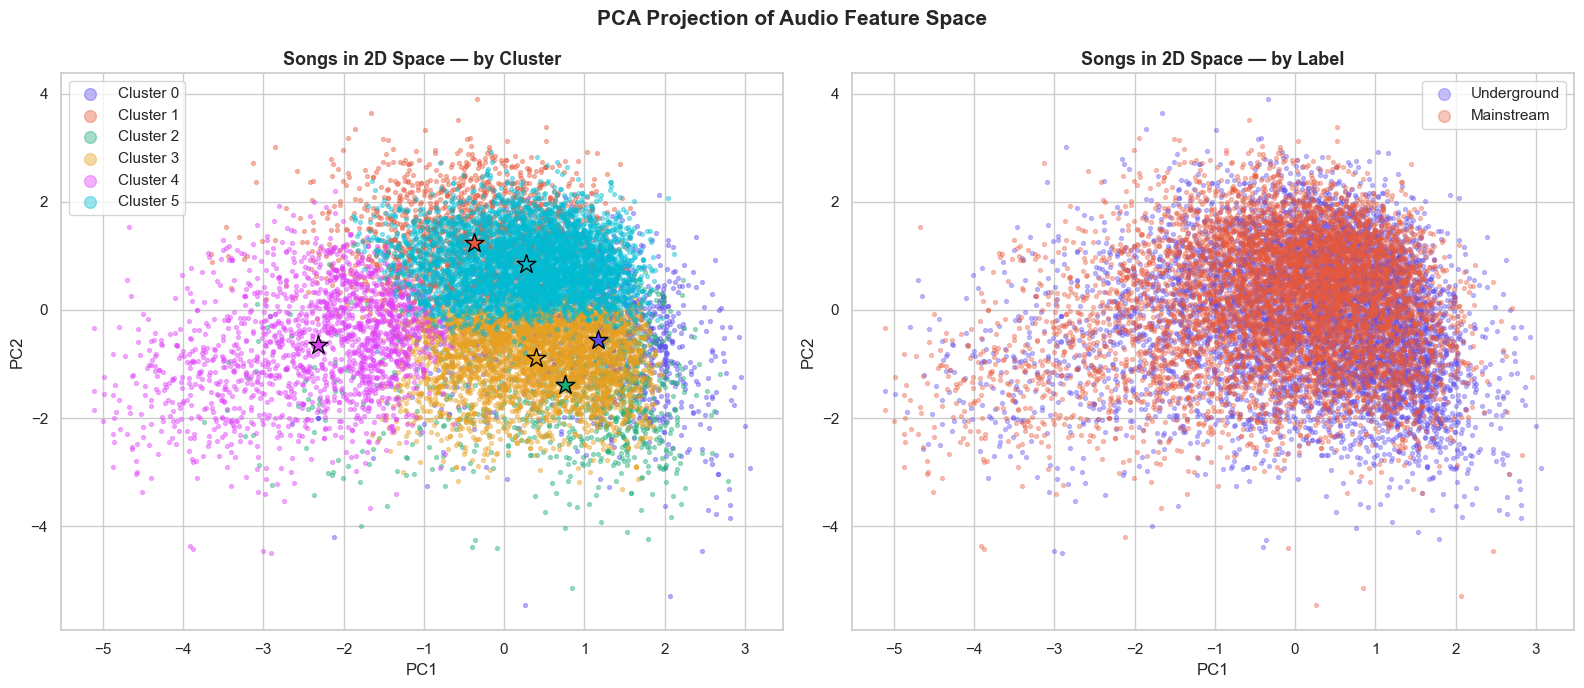

In [13]:
# Add PCA coords to the DataFrame
df_model['pc1'] = X_pca[:, 0]
df_model['pc2'] = X_pca[:, 1]

cluster_colors = ['#5B4CF0', '#E8593C', '#1DAE77', '#E8A020', '#E040FB', '#00BCD4']
cluster_names  = [f'Cluster {i}' for i in range(K)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: colour by cluster
for k in range(K):
    mask = df_model['cluster'] == k
    axes[0].scatter(df_model.loc[mask, 'pc1'], df_model.loc[mask, 'pc2'],
                    c=cluster_colors[k], alpha=0.4, s=8, label=f'Cluster {k}')

# Plot cluster centroids (transformed through PCA)
centroids_pca = pca.transform(kmeans.cluster_centers_)
for k in range(K):
    axes[0].scatter(centroids_pca[k, 0], centroids_pca[k, 1],
                    c=cluster_colors[k], s=200, marker='*', edgecolors='black', linewidths=1, zorder=5)

axes[0].set_title('Songs in 2D Space — by Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3, fontsize=11)

# Right: colour by label (underground vs mainstream)
for label, color in [('underground', C_UNDERGROUND), ('mainstream', C_MAINSTREAM)]:
    mask = df_model['label'] == label
    axes[1].scatter(df_model.loc[mask, 'pc1'], df_model.loc[mask, 'pc2'],
                    c=color, alpha=0.35, s=8, label=label.capitalize())

axes[1].set_title('Songs in 2D Space — by Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3, fontsize=11)

plt.suptitle('PCA Projection of Audio Feature Space', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('output_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 7 — Name and interpret each cluster
This is where data science becomes storytelling. Look at the audio features of each cluster and give them meaningful names.

In [14]:
# Calculate mean audio features per cluster
cluster_profiles = df_model.groupby('cluster')[FEATURES + ['track_popularity']].mean().round(3)

print('=== CLUSTER AUDIO PROFILES ===')
print('(Use these to name your clusters)\n')
print(cluster_profiles.to_string())

print('\n=== CLUSTER COMPOSITION ===')
comp = df_model.groupby(['cluster', 'label']).size().unstack(fill_value=0)
comp['total'] = comp.sum(axis=1)
comp['underground_%'] = (comp['underground'] / comp['total'] * 100).round(1)
print(comp)

print('\n=== TOP 5 SONGS PER CLUSTER (by popularity) ===')
for k in range(K):
    print(f'\nCluster {k}:')
    top = df_model[df_model['cluster'] == k].nlargest(5, 'track_popularity')[['track_name', 'track_artist', 'track_popularity']]
    print(top.to_string(index=False))

=== CLUSTER AUDIO PROFILES ===
(Use these to name your clusters)

         danceability  energy  speechiness  acousticness  instrumentalness  liveness  valence  track_popularity
cluster                                                                                                        
0               0.601   0.785        0.106         0.114             0.049     0.574    0.522            39.446
1               0.732   0.656        0.308         0.182             0.006     0.169    0.534            44.394
2               0.666   0.763        0.074         0.090             0.752     0.174    0.389            24.954
3               0.550   0.748        0.065         0.070             0.021     0.160    0.354            41.333
4               0.605   0.440        0.071         0.587             0.047     0.149    0.391            45.344
5               0.737   0.731        0.075         0.139             0.014     0.147    0.707            44.913

=== CLUSTER COMPOSITION ===
label    

---
## Cell 8 — Save model outputs

In [15]:
import joblib  # For saving sklearn models

# Save the DataFrame with cluster labels and PCA coordinates
df_model.to_csv('df_with_clusters.csv', index=False)
print('✅ Saved df_with_clusters.csv')

# Save the model objects (needed for the Streamlit dashboard)
joblib.dump(kmeans,  'kmeans_model.pkl')
joblib.dump(scaler,  'scaler.pkl')
joblib.dump(pca,     'pca_model.pkl')
print('✅ Saved kmeans_model.pkl, scaler.pkl, pca_model.pkl')

# Save cluster profiles for the dashboard
cluster_profiles.to_csv('cluster_profiles.csv')
print('✅ Saved cluster_profiles.csv')

print('\n✅ Phase 3 complete! Move to phase4_dashboard.py')

✅ Saved df_with_clusters.csv
✅ Saved kmeans_model.pkl, scaler.pkl, pca_model.pkl
✅ Saved cluster_profiles.csv

✅ Phase 3 complete! Move to phase4_dashboard.py
